## 판다스를 활용한 다층퍼셉트론 학습

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# =========================
# 1️⃣ 데이터 불러오기
# =========================

df=pd.read_csv("./pima-indians-diabetes3.csv")

In [2]:
df.head()

,pregnant,plasma,pressure,thickness,insulin,bmi,pedigree,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# =========================
# 2️⃣ 데이터 요약 통계
# =========================
# 평균, 최솟값, 최댓값 등 확인
df.describe()

,pregnant,plasma,pressure,thickness,insulin,bmi,pedigree,age,diabetes
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
# =========================
# 3️⃣ 변수 간 상관관계 계산
# =========================
df.corr()

,pregnant,plasma,pressure,thickness,insulin,bmi,pedigree,age,diabetes
pregnant,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
plasma,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
pressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
thickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
bmi,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
pedigree,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
diabetes,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


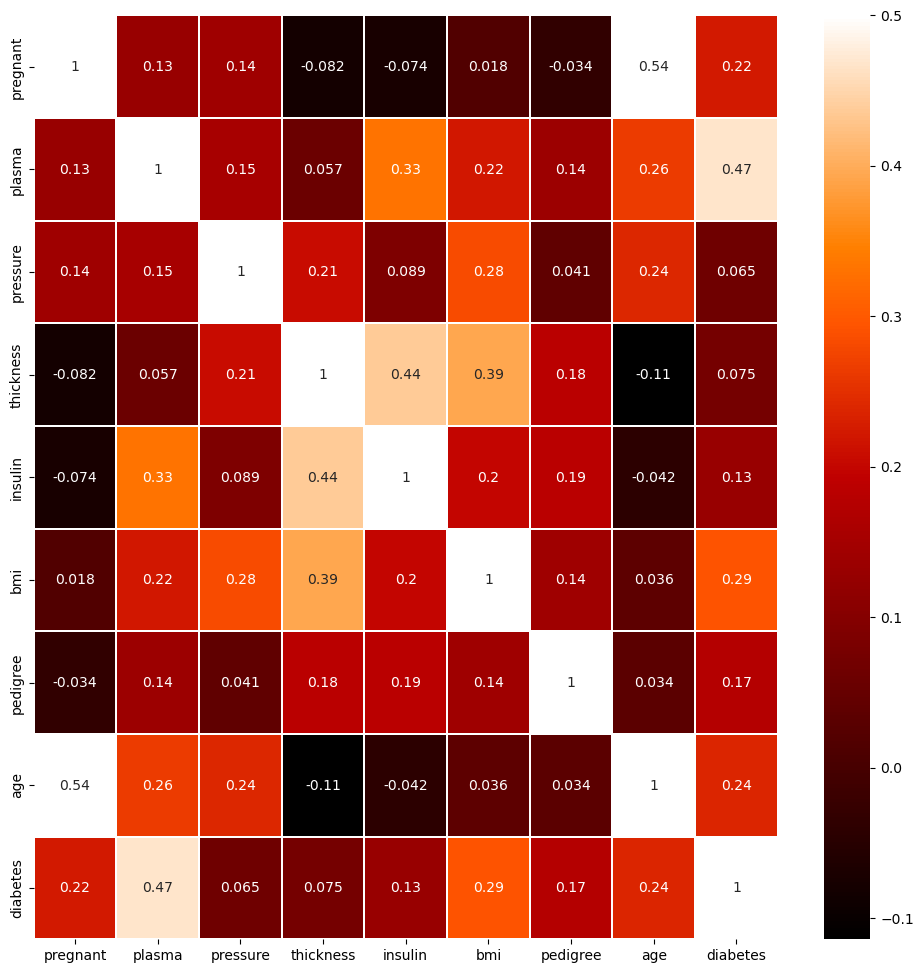

In [ ]:
# =========================
# 4️⃣ 히트맵(Heatmap) 색상 설정
# =========================

# matplotlib에서 제공하는 컬러맵 중 하나
# 값이 작을수록 어두운 색, 클수록 밝고 뜨거운 색으로 표시됨
# → 상관관계가 강한 부분을 색으로 강조하기 위해 사용
colormap=plt.cm.gist_heat



# =========================
# 그래프 전체 크기 설정
# =========================

# 히트맵이 너무 작게 나오지 않도록
# 가로 12인치, 세로 12인치 크기의 도화지를 만듦
plt.figure(figsize=(12,12))


# =========================
# 상관관계 히트맵 그리기
# =========================
sns.heatmap(df.corr(), # 🔹 각 변수 간 상관계수 계산 결과
                        #    값 범위: -1 ~ 1
                        #    1에 가까울수록 강한 양의 상관관계

            linewidth=0.1, 
                        # 🔹 각 셀(칸) 사이의 경계선 두께
                        #    0이면 칸 구분이 흐려짐
                        #    값이 크면 표처럼 또렷해
            vmax=0.5,  # 🔹 색상 최대값 제한
                        #    상관계수가 0.5 이상이어도
                        #    같은 가장 진한 색으로 표현
                        #    → 색 대비를 부드럽게 만들어
                        #      작은 차이도 보기 쉽게 함
            cmap=colormap,# 🔹 위에서 지정한 컬러맵 사용
                        #    상관관계가 강할수록 더 진한 색
            linecolor='white',
            # 🔹 셀 사이 경계선 색상
            #    흰색으로 하면 칸이 더 잘 구분됨

            annot=True)
 # 🔹 각 셀 안에 상관계수 숫자를 표시
#    색 + 숫자를 동시에 확인 가능


plt.show()

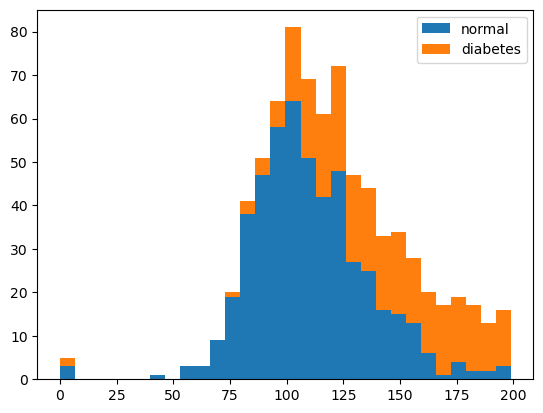

In [ ]:
## 중요한 데이터 추출하기
## =========================
## 중요한 데이터(혈당) 분석
## =========================

# 그래프 경고 메시지 숨기기 (결과에는 영향 없음)
import warnings
warnings.filterwarnings("ignore")

# 정상인과 당뇨 환자의 혈당(plasma) 분포를
# 한 그래프에서 비교하는 히스토그램

    # x에 리스트로 여러 그룹의 데이터를 넣으면
    # 동시에 여러 분포를 비교할 수 있다
plt.hist(x=[df.plasma[df.diabetes==0], # 정상인의 혈당 값
            df.plasma[df.diabetes==1]], # 당뇨 환자의 혈당 값
             # 혈당 값을 30개의 구간으로 나누어 표현
            bins=30,
            # 같은 구간의 막대를 위로 쌓아서 표시
            # → 두 그룹의 비율을 직관적으로 확인 가능
            histtype='barstacked',
             # 각 데이터 그룹의 이름 (범례용)
            label=['normal','diabetes'])

# 그래프 범례 표시
plt.legend()

(array([[  9.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  15.,  25.,  51.,
          64.,  60.,  58.,  51.,  56.,  37.,  34.,  15.,  11.,  11.,   1.,
           0.,   1.,   0.,   1.,   0.,   0.,   0.,   0.],
        [ 11.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  15.,  25.,  57.,
          74.,  83.,  94.,  91., 100.,  70.,  54.,  29.,  29.,  20.,   4.,
           4.,   4.,   1.,   1.,   1.,   0.,   0.,   1.]]),
 array([ 0.        ,  2.23666667,  4.47333333,  6.71      ,  8.94666667,
        11.18333333, 13.42      , 15.65666667, 17.89333333, 20.13      ,
        22.36666667, 24.60333333, 26.84      , 29.07666667, 31.31333333,
        33.55      , 35.78666667, 38.02333333, 40.26      , 42.49666667,
        44.73333333, 46.97      , 49.20666667, 51.44333333, 53.68      ,
        55.91666667, 58.15333333, 60.39      , 62.62666667, 64.86333333,
        67.1       ]),
 <a list of 2 BarContainer objects>)

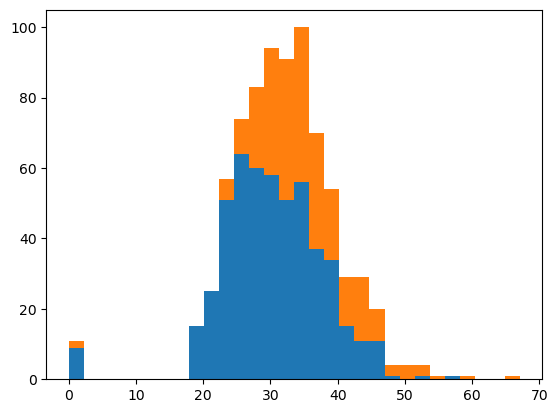

In [ ]:
# BMI 값의 분포를 히스토그램으로 그린다
# 정상인과 당뇨 환자의 BMI를 한 그래프에서 비교
plt.hist(    
    # x에 리스트로 여러 그룹의 데이터를 넣으면
    # 히스토그램을 동시에 여러 개 그릴 수 있다
    x=[df.bmi[df.diabetes==0],# 당뇨가 없는 사람들의 BMI
            df.bmi[df.diabetes==1]], # 당뇨가 있는 사람들의 BMI
             # BMI 값을 30개의 구간으로 나누어 표시
            bins=30,
            # 같은 구간의 막대를 위로 쌓아서 그림
             # → 정상인 + 당뇨 환자의 분포 비교가 쉬워짐
            histtype='barstacked',
            # 각 데이터 그룹의 이름 (범례에 표시됨)
            label=['normal','diabetes'])

In [ ]:
# =====================================
# 1️⃣ 필요한 라이브러리 불러오기
# =====================================
# Sequential : 층을 위에서 아래로 차례대로 쌓는 모델
from tensorflow.keras.models import Sequential

# Dense : 가장 기본적인 신경망 층 (모든 입력을 전부 연결)
from tensorflow.keras.layers import Dense

In [ ]:
# =====================================
# 2️⃣ 입력 데이터(X)와 정답(y) 분리
# =====================================

# df : pandas DataFrame (이미 CSV로 불러와져 있다고 가정)

# X → 입력 데이터
# iloc[:, 0:8] :
#   모든 행(:)
#   0번 열부터 7번 열까지 → 총 8개 특징(feature)
#   (예: 혈당, BMI, 나이 등)

X=df.iloc[:,0:8]

# y → 정답 데이터
# iloc[:, 8] :
#   8번 열 하나만 선택
#   (당뇨면 1, 아니면 0)
y=df.iloc[:,8]

In [ ]:
# =====================================
# 3️⃣ 모델 뼈대 만들기
# =====================================

# Sequential 모델 생성
# 아직 아무 층도 없는 "빈 신경망"
model=Sequential()



# =====================================
# 4️⃣ 첫 번째 은닉층 (Dense_1)
# =====================================
model.add(Dense(12, # 🔹 뉴런 개수 = 12개
                input_dim=8,# 🔹 입력값 개수 = 8개 (X의 열 개수)
                activation='relu', # 🔹 활성화 함수: ReLU
                              #     음수 → 0
                              #     양수 → 그대로
                name='Dense_1')) # 🔹 모델 요약(summary)에 표시될 층 이름

# 👉 의미:
# 8개의 입력 정보를 받아서
# 12개의 새로운 숫자로 변환
# (여러 관점에서 데이터 해석)


# =====================================
# 5️⃣ 두 번째 은닉층 (Dense_2)
# =====================================

model.add(Dense(8, # 🔹 뉴런 개수 = 8개
                activation='relu', # 🔹 ReLU 활성화 함수
                name='Dense_2')) # 🔹 층 이름

# 👉 여기서 input_dim을 안 써도 되는 이유:
# 이전 층(Dense_1)의 출력(12개)이
# 자동으로 입력으로 들어가기 때문

# 👉 의미:
# 12개의 정보를 다시 8개로 정리
# (중요한 정보만 압축)


# =====================================
# 6️⃣ 출력층 (Dense_3)
# =====================================


model.add(Dense(1,# 🔹 출력값 1개
                activation='sigmoid',# 🔹 sigmoid 함수
                                      #     출력값: 0 ~ 1
                                      #     확률처럼 해석 가능
                name='Dense_3')) # 🔹 출력층 이름

# 👉 의미:
# "이 사람이 당뇨일 확률은?"
# 하나의 숫자로 최종 판단


# =====================================
# 7️⃣ 모델 구조 요약 출력
# =====================================

# 지금까지 만든 모델의 구조를
# 표 형태로 한눈에 보여줌

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Dense_1 (Dense)                 │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_2 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)


## 🔴 한 줄 핵심부터

> **Param #은 “이 모델이 공부하면서 외워야 하는 숫자의 개수”야.**
> 👉 숫자가 많을수록 **더 복잡하게 생각할 수 있지만**,
> 👉 너무 많으면 **헷갈려서 과적합**이 생길 수 있어.

---

## 🧠 먼저 진짜 중요한 개념 2개만 알자

딥러닝에서 뉴런 하나는 항상 이걸 가지고 있어 👇

### ① 가중치(weight)

* “이 입력을 얼마나 중요하게 볼까?”

### ② 바이어스(bias)

* “아무 입력이 없어도 기본으로 더하는 값”

📌 **뉴런 1개 = 가중치 여러 개 + bias 1개**

---

## 🔹 Dense_1 → Param 108개 (왜?)

### 상황 정리

* 입력값: **8개**
* 뉴런: **12개**

---

### 🔹 뉴런 하나만 먼저 생각해보자

입력이 8개면
👉 **가중치도 8개 필요**

그리고 항상
👉 **bias 1개 추가**

즉,

```
뉴런 1개 = (가중치 8개 + bias 1개) = 9개
```

---

### 🔹 뉴런이 12개니까?

```
9 × 12 = 108
```

✅ 그래서 **Dense_1의 Param = 108개**

---

### 🧠 비유로 보면

> 문제 8개를 보고
> 학생 12명이 각각
> “이건 중요, 이건 덜 중요”
> 점수를 매긴다고 생각해봐

👉 학생 1명당 점수표 9개
👉 12명이면 108개

---

## 🔹 Dense_2 → Param 104개 (왜?)

### 상황

* 입력: **12개** (Dense_1 출력)
* 뉴런: **8개**

---

### 뉴런 1개당

```
(입력 12개 + bias 1개) = 13개
```

### 뉴런 8개니까

```
13 × 8 = 104
```

✅ 그래서 **Dense_2의 Param = 104개**

---

## 🔹 Dense_3 → Param 9개 (왜?)

### 상황

* 입력: **8개**
* 뉴런: **1개** (최종 결과)

---

### 계산

```
(8 + 1) × 1 = 9
```

👉 **가중치 8개 + bias 1개**

---

## 🧠 전체 구조를 진짜 쉽게 그려보면

```
입력 정보 8개
   ↓
[ Dense_1 ]
- 뉴런 12개
- 각자 숫자 9개씩 외움
→ 총 108개
   ↓
[ Dense_2 ]
- 뉴런 8개
- 각자 숫자 13개씩 외움
→ 총 104개
   ↓
[ Dense_3 ]
- 뉴런 1개
- 숫자 9개 외움
→ 총 9개
```

---

## ✅ 진짜로 이것만 기억해도 된다

### 🔑 Param 계산 공식 (외워도 됨)

```
(입력 개수 + 1) × 뉴런 개수
```

* `+1` → bias 때문
* Param # → 모델이 **공부하면서 조절하는 숫자**

---

## 🔥 한 줄 최종 요약

> **Param #은 “이 인공지능이 외우고 조절해야 할 숫자 개수”이고,
> (입력 개수 + 1) × 뉴런 개수로 계산된다.**



In [ ]:
# =====================================
# 1️⃣ 모델 컴파일 (공부 방법 설정)
# =====================================


model.compile(loss='binary_crossentropy', # 이진 분류용 오답 계산법
                                          # (정답 0/1, sigmoid 출력과 궁합 최고)
              optimizer='adam',     # 틀린 걸 자동으로 잘 고쳐주는 방법
                                    # 가장 많이 쓰는 기본 optimizer
              metrics=['accuracy'])# 학습 중에 정확도를 함께 출력


# =====================================
# 2️⃣ 모델 학습 시작
# =====================================
history=model.fit(X,y,# 입력 데이터(X)와 정답(y)
                  epochs=100,  # 전체 데이터를 100번 반복 학습
                  batch_size=5) # 5개씩 나눠서 공부

Epoch 1/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5521 - loss: 1.2443
Epoch 2/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 950us/step - accuracy: 0.6302 - loss: 0.7525
Epoch 3/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6432 - loss: 0.6959  
Epoch 4/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6458 - loss: 0.6782  
Epoch 5/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 973us/step - accuracy: 0.6471 - loss: 0.6655
Epoch 6/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6562 - loss: 0.6676  
Epoch 7/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 886us/step - accuracy: 0.6497 - loss: 0.6545
Epoch 8/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 897us/step - accuracy: 0.6602 - loss: 0.6498
Epoch 9/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 910us/step - accuracy: 0.6615 - loss: 0.6476
Epoch 10/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 903us/step - accuracy: 0.6576 - loss: 0.6470
Epoch 11/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 896us/step - accuracy: 0.6602 - loss: 0.6400
Epoch 12/100
154/154 